# AMS 597 – Inside Airbnb NYC: Data Cleaning
**Dataset:** Inside Airbnb – New York City Listings  
**Source:** https://insideairbnb.com/get-the-data/  
**File:** `listings 2 (1).csv`  
**Goal:** Load the raw dataset, inspect it, and produce a clean DataFrame ready for analysis.

> **Note:** The working CSV includes a numeric **nightly `price`** (USD) in every row. The cleaning pipeline **parses** `price` if it appears as text (e.g. `$1,234` in other exports), **treats non-positive values as invalid**, fills any remaining missing prices with the **global median**, and **winsorizes** extreme high values at the 99.5th percentile to limit scrape errors. Column `estimated_revenue_l365d` is entirely empty and is dropped.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## 2. Load Raw Data

In [2]:
df_raw = pd.read_csv('listings 2 (1).csv', low_memory=False)
print(f'Shape: {df_raw.shape}')  # 36,261 rows × 85 columns
df_raw.head(3)

Shape: (36261, 85)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2539,https://www.airbnb.com/rooms/2539,20251204025441,2025-12-06,previous scrape,Superfast Wi-Fi. Clean & quiet home by the park,"Bright, serene room in a renovated apartment h...",Close to Prospect Park and Historic Ditmas Park,https://a0.muscache.com/pictures/hosting/Hosti...,2787,https://www.airbnb.com/users/show/2787,1462506323032802048.0000,https://www.airbnb.com/users/profile/146250632...,John,2008-09-07,17.0000,2.0000,14.0000,11.0000,"New York, NY",Educated professional living in Brooklyn. I l...,within an hour,100%,79%,f,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,Gravesend,7.0000,13.0000,"['email', 'phone']",t,t,Neighborhood highlights,Kensington,Brooklyn,40.6453,-73.9724,Private room in condo,Private room,2,NaN,1 shared bath,1.0000,NaN,"[""Cleaning available during stay"", ""Wine glass...",68.3600,30,730,30.0000,30.0000,730.0000,730.0000,30.0000,730.0000,NaN,t,30,60,90,364,2025-12-06,9,0,0,26,0,0,NaN,2015-12-04,2018-10-19,4.8900,4.8800,5.0000,5.0000,5.0000,4.7500,4.8800,NaN,f,7,1,6,0,0.0700
1,2595,https://www.airbnb.com/rooms/2595,20251204025441,2025-12-05,city scrape,Skylit Studio Oasis | Midtown Manhattan Sanctuary,Prime Midtown | Spacious 500 Sq Ft | Pyramid S...,Centrally located in the heart of Manhattan ju...,https://a0.muscache.com/pictures/hosting/Hosti...,2845,https://www.airbnb.com/users/show/2845,1462506326262395392.0000,https://www.airbnb.com/users/profile/146250632...,Jennifer,2008-09-09,17.0000,2.0000,14.0000,11.0000,"Woodstock, NY",A New Yorker since 2000! My passion is creatin...,within a day,60%,26%,f,https://a0.muscache.com/im/pictures/user/50fc5...,https://a0.muscache.com/im/pictures/user/50fc5...,Midtown,7.0000,9.0000,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Midtown,Manhattan,40.7536,-73.9856,Entire rental unit,Entire home/apt,1,1.0000,1 bath,0.0000,1.0000,"[""Cleaning available during stay"", ""Dishes and...",212.6500,30,1125,30.0000,30.0000,1125.0000,1125.0000,30.0000,1125.0000,NaN,t,30,60,90,319,2025-12-05,47,0,0,27,0,0,NaN,2009-11-21,2022-06-21,4.6800,4.7300,4.6300,4.7700,4.8000,4.8100,4.4000,NaN,f,3,3,0,0,0.2400
2,6848,https://www.airbnb.com/rooms/6848,20251204025441,2025-12-04,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,https://www.airbnb.com/users/show/15991,1462506783043501056.0000,ht

## 3. Initial Inspection

In [3]:
# Data types
df_raw.dtypes

id                                                int64
listing_url                                         str
scrape_id                                         int64
last_scraped                                        str
source                                              str
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 85, dtype: object

In [4]:
# Missing value counts and percentages
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_%', ascending=False)

,missing_count,missing_%
estimated_revenue_l365d,36261,100.0000
calendar_updated,36261,100.0000
license,31233,86.1300
neighbourhood,18130,50.0000
neighborhood_overview,18131,50.0000
host_about,15483,42.7000
host_response_rate,15173,41.8400
host_response_time,15173,41.8400
beds,14891,41.0700
bathrooms,14806,40.8300


In [5]:
# Quick stats before any transformation
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,36261.0000,NaN,NaN,NaN,487573595724604160.0000,562623600732273152.0000,2539.0000,21756084.0000,51724883.0000,1005170940682176000.0000,1567716861030050816.0000
listing_url,36261,36261,https://www.airbnb.com/rooms/2539,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scrape_id,36261.0000,NaN,NaN,NaN,20251204025441.0000,0.0039,20251204025441.0000,20251204025441.0000,20251204025441.0000,20251204025441.0000,20251204025441.0000
last_scraped,36261,5,2025-12-05,21904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,36261,2,city scrape,21463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
calculated_host_listings_count,36261.0000,NaN,NaN,NaN,68.3333,224.5161,1.0000,1.0000,2.0000,9.0000,1189.0000
calculated_host_listings_count_entire_homes,36261.0000,NaN,NaN,NaN,51.3464,214.7376,0.0000,0.0000,1.0000,2.0000,1189.0000
calculated_host_listings_count_private_rooms,36261.0000,NaN,NaN,NaN,16.2421,76.8296,0.0000,0.0000,1.0000,2.0000,567.0000
calculated_host_listings_count_shared_rooms,36261.0000,NaN,NaN,NaN,0.0930,1.4064,0.0000,0.0000,0.0000,0.0000,34.0000


## 4. Data Cleaning

This section follows a standard workflow suitable for written documentation (matches typical assignment rubrics): **document variables**, **correct types**, **handle missingness with explicit rules**, **fix invalid values**, **remove duplicates**, **validate ranges**.

Steps:
1. Drop irrelevant / URL / entirely-empty / free-text columns  
2. Fix percentage columns → float  
3. Fix boolean columns (`t`/`f` → `True`/`False`)  
4. Parse date columns  
5. Handle remaining missing values (besides `price`)  
6. Clean and validate **`price`** (parse, invalids, median fill, winsorize) — §4.5b  
7. Remove duplicate rows  
8. Validate key variable ranges

### 4.1 Drop Irrelevant / Empty Columns

In [6]:
cols_to_drop = [
    # URL / scrape metadata
    'listing_url', 'scrape_id', 'source', 'picture_url',
    'host_url', 'host_profile_id', 'host_profile_url',
    'host_thumbnail_url', 'host_picture_url',
    'calendar_last_scraped',      # duplicate of last_scraped

    # 100% empty columns (price is filled in §4.5b; keep it)
    'estimated_revenue_l365d',    # entirely empty in this dataset version
    'calendar_updated',           # entirely empty

    # Almost entirely empty
    'license',

    # Redundant geography (use neighbourhood_cleansed instead)
    'neighbourhood',

    # Free-text / list columns not used in statistical analysis
    'name', 'description', 'neighborhood_overview',
    'host_about', 'host_location',
    'amenities', 'host_verifications',
]

df = df_raw.drop(columns=cols_to_drop)
print(f'Columns remaining: {df.shape[1]}')

Columns remaining: 64


### 4.2 Clean Percentage Columns

In [7]:
pct_cols = ['host_response_rate', 'host_acceptance_rate']

for col in pct_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('%', '', regex=False)
        .str.strip()
        .replace('nan', np.nan)
        .replace('', np.nan)
        .astype(float)
        / 100
    )

df[pct_cols].describe()

,host_response_rate,host_acceptance_rate
count,21088.0000,21520.0000
mean,0.9119,0.7557
std,0.2281,0.3016
min,0.0000,0.0000
25%,0.9800,0.5600
50%,1.0000,0.9000
75%,1.0000,1.0000
max,1.0000,1.0000


### 4.3 Convert Boolean Columns (`t`/`f` → bool)

In [8]:
bool_cols = [
    'host_is_superhost',
    'host_has_profile_pic',
    'host_identity_verified',
    'has_availability',
    'instant_bookable',
]

bool_map = {'t': True, 'f': False}

for col in bool_cols:
    df[col] = df[col].map(bool_map)

df[bool_cols].head()

,host_is_superhost,host_has_profile_pic,host_identity_verified,has_availability,instant_bookable
0,False,True,True,True,False
1,False,True,True,True,False
2,True,True,True,True,False
3,False,True,True,True,False
4,False,True,True,True,False


### 4.4 Parse Date Columns

In [9]:
date_cols = ['last_scraped', 'host_since', 'first_review', 'last_review']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df[date_cols].dtypes

last_scraped    datetime64[us]
host_since      datetime64[us]
first_review    datetime64[us]
last_review     datetime64[us]
dtype: object

### 4.5 Handle Missing Values

In [10]:
# --- Numeric columns: fill with median ---
numeric_fill_median = ['bathrooms', 'bedrooms', 'beds']

for col in numeric_fill_median:
    median_val = df[col].median()
    n_filled = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f'{col}: filled {n_filled} missing values with median ({median_val})')

bathrooms: filled 14806 missing values with median (1.0)
bedrooms: filled 6013 missing values with median (1.0)
beds: filled 14891 missing values with median (1.0)


In [11]:
# --- Review scores: fill missing with median (listings with no reviews yet) ---
review_score_cols = [
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
]

for col in review_score_cols:
    median_val = df[col].median()
    n_filled = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f'{col}: filled {n_filled} missing with median ({median_val:.4f})')

review_scores_rating: filled 11349 missing with median (4.8600)
review_scores_accuracy: filled 11360 missing with median (4.9000)
review_scores_cleanliness: filled 11351 missing with median (4.8200)
review_scores_checkin: filled 11364 missing with median (4.9500)
review_scores_communication: filled 11356 missing with median (4.9600)
review_scores_location: filled 11367 missing with median (4.8600)
review_scores_value: filled 11366 missing with median (4.7600)


In [12]:
# --- Host rate columns: fill missing with median ---
for col in pct_cols:
    median_val = df[col].median()
    n_filled = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f'{col}: filled {n_filled} missing with median ({median_val:.4f})')

host_response_rate: filled 15173 missing with median (1.0000)
host_acceptance_rate: filled 14741 missing with median (0.9000)


In [13]:
# --- Boolean columns: fill missing with False ---
for col in bool_cols:
    n_filled = df[col].isnull().sum()
    df[col] = df[col].fillna(False)
    print(f'{col}: filled {n_filled} missing with False')

host_is_superhost: filled 0 missing with False
host_has_profile_pic: filled 11 missing with False
host_identity_verified: filled 11 missing with False
has_availability: filled 5634 missing with False
instant_bookable: filled 0 missing with False


In [14]:
# --- Categorical: fill missing host_response_time with 'unknown' ---
df['host_response_time'] = df['host_response_time'].fillna('unknown')

# --- reviews_per_month: 0 for listings with no reviews ---
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

### 4.5b Clean and validate `price`

**Goal:** Treat nightly price as a numeric analysis variable with transparent rules.

1. **Coerce** to float (handles plain numbers in this file; also strips `$` and commas if the column is ever string-typed, as in raw Inside Airbnb downloads).  
2. **Invalid values:** missing or non-positive prices are set to missing (bad or incomplete scrape).  
3. **Imputation:** remaining missing prices get the **dataset median** (simple, documented rule).  
4. **Outliers:** cap values above the **99.5th percentile** (winsorize) to reduce the influence of erroneous extreme listings without dropping rows.

Document these choices in any report appendix so they align with your course PDF requirements.

In [15]:
pcol = df['price']

if pcol.dtype == object or str(pcol.dtype).startswith('string'):
    cleaned = (
        pcol.astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
        .replace({'nan': np.nan, 'None': np.nan, '': np.nan})
    )
    df['price'] = pd.to_numeric(cleaned, errors='coerce')
else:
    df['price'] = pd.to_numeric(pcol, errors='coerce')

missing_before = df['price'].isna().sum()
nonpositive = (df['price'].notna()) & (df['price'] <= 0)
n_bad_sign = int(nonpositive.sum())
df.loc[nonpositive, 'price'] = np.nan

median_price = df['price'].median()
df['price'] = df['price'].fillna(median_price)

hi_cap = df['price'].quantile(0.995)
n_capped = int((df['price'] > hi_cap).sum())
df['price'] = df['price'].clip(upper=hi_cap)

print(f'price: missing before coerce/clean {missing_before:,}; non-positive set to NA: {n_bad_sign}')
print(f'price: median imputation value ${median_price:.2f}; winsor cap at 99.5% = ${hi_cap:.2f} ({n_capped} rows capped)')
print(df['price'].describe())

price: missing before coerce/clean 0; non-positive set to NA: 0
price: median imputation value $133.18; winsor cap at 99.5% = $296.00 (182 rows capped)
count   36261.0000
mean      143.2103
std        65.2229
min        33.9200
25%        79.4900
50%       133.1800
75%       208.8500
max       296.0020
Name: price, dtype: float64


### 4.6 Remove Duplicate Rows

In [16]:
n_before = len(df)
df = df.drop_duplicates(subset='id')
print(f'Duplicate rows removed: {n_before - len(df)}  |  Remaining: {len(df)}')

Duplicate rows removed: 0  |  Remaining: 36261


### 4.7 Validate Key Variable Ranges

In [17]:
assert df['availability_365'].between(0, 365).all(), 'availability_365 out of range'
assert df['review_scores_rating'].between(0, 5).all(), 'review_scores_rating out of range'
assert df['host_response_rate'].between(0, 1).all(), 'host_response_rate out of range'
assert df['host_acceptance_rate'].between(0, 1).all(), 'host_acceptance_rate out of range'
assert df['price'].notna().all(), 'price must be fully imputed'
assert df['price'].gt(0).all(), 'price must be positive'
print('All range checks passed.')

All range checks passed.


## 5. Post-Cleaning Summary

In [18]:
print('=== Clean Dataset Overview ===')
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
print()
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if remaining_missing.empty:
    print('No missing values remain in the key analysis columns.')
else:
    print('Remaining missing values:')
    print(remaining_missing)

=== Clean Dataset Overview ===
Rows: 36,261   Columns: 64

Remaining missing values:
host_name                       11
host_since                      11
hosts_time_as_user_years       416
hosts_time_as_user_months      416
hosts_time_as_host_years       849
hosts_time_as_host_months      849
host_neighbourhood            7379
host_listings_count             11
host_total_listings_count       11
bathrooms_text                 108
minimum_minimum_nights           4
maximum_minimum_nights           4
minimum_maximum_nights           4
maximum_maximum_nights           4
first_review                 11349
last_review                  11349
dtype: int64


In [19]:
# Key analysis variables (price cleaned in §4.5b)
key_vars = [
    'price',
    'room_type', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed',
    'number_of_reviews', 'availability_365', 'review_scores_rating',
    'estimated_occupancy_l365d', 'reviews_per_month',
]
df[key_vars].describe(include='all')

,price,room_type,neighbourhood_cleansed,neighbourhood_group_cleansed,number_of_reviews,availability_365,review_scores_rating,estimated_occupancy_l365d,reviews_per_month
count,36261.0000,36261,36261,36261,36261.0000,36261.0000,36261.0000,36261.0000,36261.0000
unique,NaN,4,224,5,NaN,NaN,NaN,NaN,NaN
top,NaN,Entire home/apt,Bedford-Stuyvesant,Manhattan,NaN,NaN,NaN,NaN,NaN
freq,NaN,19452,2613,16220,NaN,NaN,NaN,NaN,NaN
mean,143.2103,NaN,NaN,NaN,27.3473,167.4440,4.7647,46.3930,0.5552
std,65.2229,NaN,NaN,NaN,68.9282,149.7623,0.3927,84.7263,1.5663
min,33.9200,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000
25%,79.4900,NaN,NaN,NaN,0.0000,0.0000,4.7500,0.0000,0.0000
50%,133.1800,NaN,NaN,NaN,3.0000,160.0000,4.8600,0.0000,0.0800
75%,208.8500,NaN,NaN,NaN,22.0000,335.0000,4.9400,60.0000,0.4600


In [20]:
# Distribution of room types
print(df['room_type'].value_counts())
print()
# Borough distribution
print(df['neighbourhood_group_cleansed'].value_counts())

room_type
Entire home/apt    19452
Private room       16201
Hotel room           331
Shared room          277
Name: count, dtype: int64

neighbourhood_group_cleansed
Manhattan        16220
Brooklyn         13282
Queens            5256
Bronx             1139
Staten Island      364
Name: count, dtype: int64


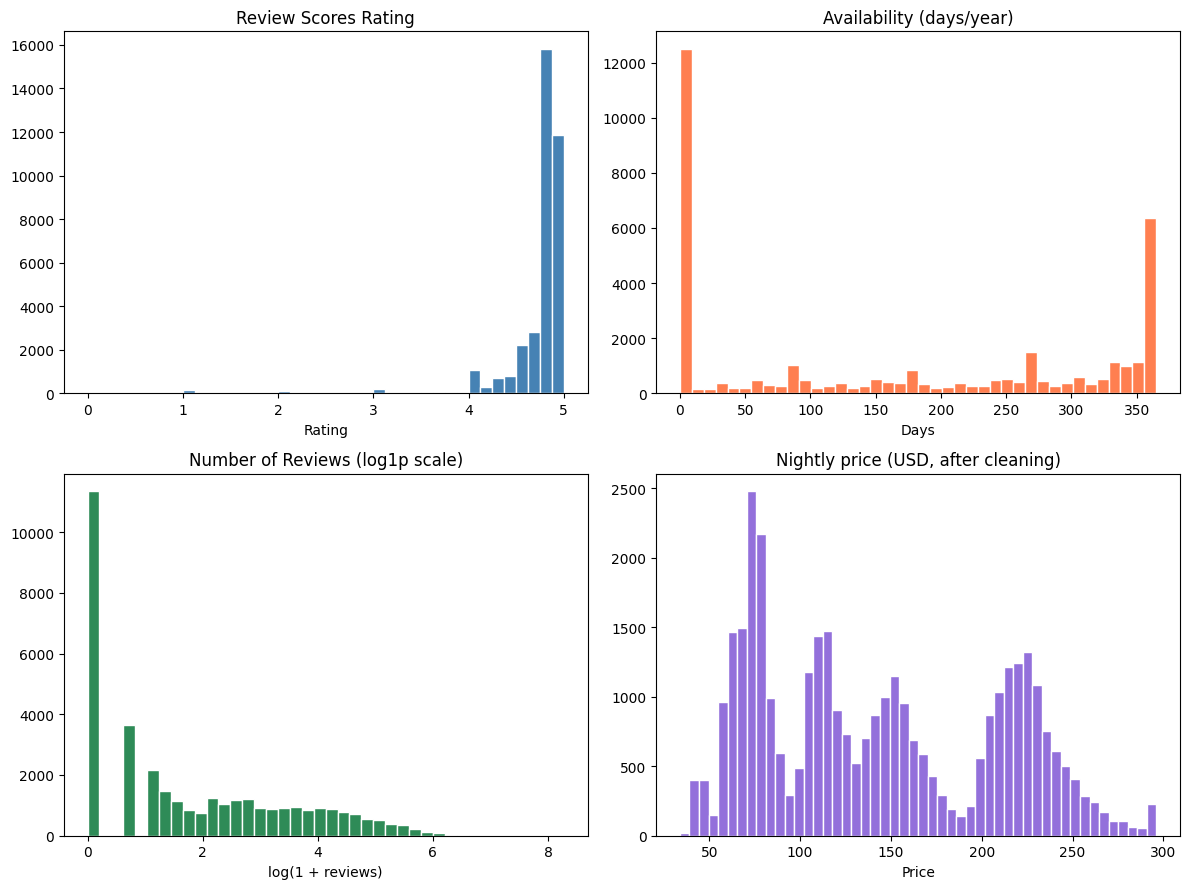

In [21]:
# Distributions of key continuous variables
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(df['review_scores_rating'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Review Scores Rating')
axes[0, 0].set_xlabel('Rating')

axes[0, 1].hist(df['availability_365'], bins=40, color='coral', edgecolor='white')
axes[0, 1].set_title('Availability (days/year)')
axes[0, 1].set_xlabel('Days')

axes[1, 0].hist(np.log1p(df['number_of_reviews']), bins=40, color='seagreen', edgecolor='white')
axes[1, 0].set_title('Number of Reviews (log1p scale)')
axes[1, 0].set_xlabel('log(1 + reviews)')

axes[1, 1].hist(df['price'], bins=50, color='mediumpurple', edgecolor='white')
axes[1, 1].set_title('Nightly price (USD, after cleaning)')
axes[1, 1].set_xlabel('Price')

plt.tight_layout()
plt.show()

## 6. Save Clean Dataset

In [ ]:
df.to_csv('listings_clean.csv', index=False)
print('Clean dataset saved to listings_clean.csv')
print(f'Final shape: {df.shape}')